# Breast Cancer Diagnosis Classification and Clustering

This notebook analyzes a breast cancer dataset and applies both supervised and unsupervised learning techniques. The workflow includes dataset cleaning, label encoding, feature standardization, clustering with K-Means, and classification using Logistic Regression and SVM models.

**Main tasks covered**
- Removing non-informative columns
- Encoding the diagnosis label
- Preparing scaled feature data
- Applying K-Means clustering
- Training Logistic Regression and multiple SVM variants
- Comparing model performance using classification metrics


## 1. Data Loading and Initial Inspection


In [1]:
import pandas as pd

df = pd.read_csv("data.csv")
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 2. Data Cleaning and Label Encoding


In [3]:
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True)


In [4]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [5]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


In [6]:
df['diagnosis'].unique()

array([1, 0])

In [7]:
df.isnull().sum()


,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


## 3. Feature Preparation and Scaling


In [20]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


## 4. K-Means Clustering


In [10]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters


In [11]:
pd.crosstab(df['Cluster'], df['diagnosis'])


diagnosis,0,1
Cluster,,
0,13,175
1,344,37


## 5. Train/Test Split


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


## 6. Logistic Regression


In [13]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

In [ ]:
#logistic reg the best model for this data

In [14]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## 7. Support Vector Machine Models


In [15]:
from sklearn.svm import SVC

svm = SVC(kernel='linear')
svm.fit(X_train, y_train)


SVC(kernel='linear')

In [16]:
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [31]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf',gamma=0.01)
svm.fit(X_train, y_train)


SVC(gamma=0.01)

In [32]:
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [35]:
from sklearn.svm import SVC

svm = SVC(kernel='poly',degree=5)
svm.fit(X_train, y_train)
# worst ml model , will not put it for conc

SVC(degree=5, kernel='poly')

In [36]:
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8157894736842105
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        71
           1       1.00      0.51      0.68        43

    accuracy                           0.82       114
   macro avg       0.89      0.76      0.77       114
weighted avg       0.86      0.82      0.80       114



In [37]:
from sklearn.svm import SVC

svm = SVC(kernel='sigmoid')
svm.fit(X_train, y_train)
# worst ml model , will not put it for conc

SVC(kernel='sigmoid')

In [38]:
y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.956140350877193
              precision    recall  f1-score   support

           0       0.97      0.96      0.96        71
           1       0.93      0.95      0.94        43

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



## 8. Confusion Matrix Visualization


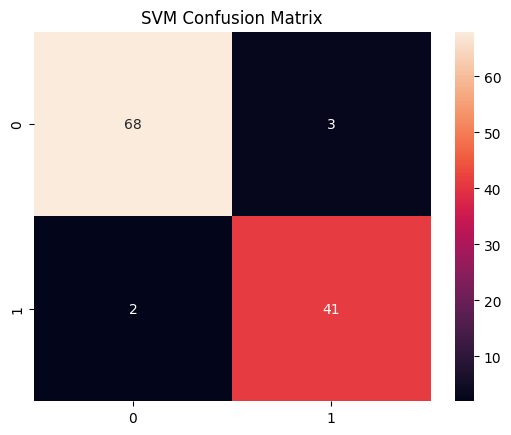

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

sns.heatmap(confusion_matrix(y_test, y_pred_svm),
            annot=True, fmt='d')
plt.title("SVM Confusion Matrix")
plt.show()


## 9. Summary

This notebook compares clustering and classification approaches for breast cancer diagnosis.  
The saved results show that **Logistic Regression achieved about 97.4% accuracy**, while **linear and RBF SVM models achieved around 95–96% accuracy** on the test data.
